In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import copy

In [2]:
# featureNormalize normalizes the features in X
# featureNormalize(X) returns a normalized version of X where the mean value of each feature is 0 
# and the standard deviation is 1. This is often a good preprocessing step to do
# when working with learning algorithms. You need to set these values correctly

def featureNormalize(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0, ddof=1)
    X_norm = (X - mu) / sigma  #(new feature value = (old feature value - mean) / standard deviation)
    return X_norm, mu, sigma


In [3]:
# plotCost plots the convergence graph

def plotCostMulti(j, alpha):
    plt.plot(range(j.size), j, "-", label=alpha)
    plt.xlabel('Number of iterations')
    plt.ylabel('Cost J')


In [13]:
# calculateHypothesis calculates the hypothesis for a given X, theta and specified training example

def calculateHypothesisMulti(X, theta, trainingExample):
    # this hypothesis is sufficiently general so that we can have any number of variables
    
    hypothesis = np.dot(X[trainingExample],theta)
    
    # ---------------------------- your code ----------------------------------
    

    return hypothesis

In [15]:
# computeCost Compute cost for linear regression with multiple variables
# J = computeCost(X, y, theta) computes the cost of using theta as the
# parameter for linear regression to fit the data points in X and y
    
def computeCostMulti(X, y, theta):
    j = 0.0     # cost
    m = len(y)  # number of training examples

    for i in range(m):
        hypothesis = calculateHypothesisMulti(X, theta, i)
        output = y[i]
        squaredError = math.pow((hypothesis - output), 2)
        j = j + squaredError

    j = j * (1.0 / (2 * m))

    return j

In [16]:
# gradientDescentMulti Performs gradient descent to learn theta
# theta = gradientDescentMulti(x, y, theta, alpha, num_iters) updates theta
# by taking num_iters gradient steps with learning rate alpha
    
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = len(y)       # number of training examples
    cost_vector = [] # will store the results of our cost function
    
    for iter in range(num_iters):
        temp_theta = copy.copy(theta)
        dimension = theta.shape[0]

        for j in range(dimension):
            # update theta and store in temporary variable temp_theta
            sigma = 0.0
            # finding new theta[i]
            for i in range(m):
                hypothesis = calculateHypothesisMulti(X, theta, i)
                output = y[i]
                
                # ----------------------------- your code ----------------------------
                sigma = sigma + (hypothesis - output) * X[i, j]
            
            # ----------------------------- your code ----------------------------
            temp_theta[j] = temp_theta[j] - ((alpha * 1.0) / m) * sigma


        theta = temp_theta
        cost_vector = np.append(cost_vector, computeCostMulti(X, y, theta))

    return theta, cost_vector


In [17]:
# normalEqn Computes the closed-form solution to linear regression
# normalEqn(X,y) computes the closed-form solution to linear regression using the normal equations.

def normalEqn(X, y):
    theta = np.linalg.pinv(X.T.dot(X)).dot(X.T).dot(y)  
    #the value of θ that minimizes J(θ) is given in closed form by the equation θ = (XTX)−1XT y.
    return theta

In [18]:
# ================ Load data ================

print('Loading data ...')

# Load Data
lines = open('ex1data2.txt', 'rb').readlines()
data = np.array([[float(f) for f in l.decode('UTF-8').split(',')] for l in lines])
X = np.array(data[:, [0, 1]])
y = np.array(data[:, 2])
m = len(y)

# Print out some data points
print('First 10 examples from the dataset:')
print(X[range(0, 10),:]) 
print(y[range(0, 10)])

Loading data ...
First 10 examples from the dataset:
[[2.104e+03 3.000e+00]
 [1.600e+03 3.000e+00]
 [2.400e+03 3.000e+00]
 [1.416e+03 2.000e+00]
 [3.000e+03 4.000e+00]
 [1.985e+03 4.000e+00]
 [1.534e+03 3.000e+00]
 [1.427e+03 3.000e+00]
 [1.380e+03 3.000e+00]
 [1.494e+03 3.000e+00]]
[399900. 329900. 369000. 232000. 539900. 299900. 314900. 198999. 212000.
 242500.]


In [19]:
# ================ Feature Normalization ================

# Scale features and set them to zero mean
print('Normalizing Features ...')

[X, mu, sigma] = featureNormalize(X)

# Add intercept term to X
X = np.hstack((np.ones((m, 1)), X))

print('mu = ', mu)
print('sigma = ', sigma)

Normalizing Features ...
mu =  [2000.68085106    3.17021277]
sigma =  [7.94702354e+02 7.60981887e-01]


Running gradient descent...


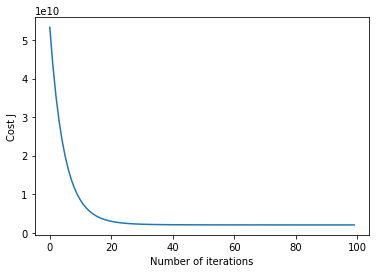

In [30]:
# ================ Gradient Descent ================

print('Running gradient descent...')

# Choose some alpha value
alpha = 0.1
num_iters = 100

# Init theta and run gradient descent
theta = np.zeros(3)
theta, j = gradientDescentMulti(X, y, theta, alpha, num_iters)
    
# Plot the convergence graph
plotCostMulti(j, alpha)
plt.show()


In [21]:
# ================ Model =================

# Display gradient descent's result
print('Theta computed from gradient descent: ')
print(theta)


Theta computed from gradient descent: 
[340403.61773803 109912.67848878  -5931.10911548]


In [38]:
# ================ Prediction =================

#  Estimate the price of a 1650 sq-ft, 3 br house

# ----------------------------------your code -------------------------------------
x_i=[1650, 3]
x_i = (x_i - mu) / sigma
x_i =np.insert(x_i,0,1)
price = np.array(x_i).dot(theta)
print('Predicted price of a 1650 sq-ft, 3 br house (Using gradient descent): ', price)

x_i=[3000, 4]
x_i = (x_i - mu) / sigma
x_i =np.insert(x_i,0,1)
price = np.array(x_i).dot(theta)
print('Predicted price of a 3000 sq-ft, 4 br house (Using gradient descent): ', price)

Predicted price of a 1650 sq-ft, 3 br house (Using gradient descent):  293228.7402569017
Predicted price of a 3000 sq-ft, 4 br house (Using gradient descent):  472148.7952590984


alpha: 0.01-> theta: [215810.61679138  61384.03125186  20273.55045338], cost: 10621009943.60025
alpha: 0.1-> theta: [340403.61773803 109912.67848878  -5931.10911548], cost: 2043502340.34307
alpha: 1-> theta: [340412.65957447 110631.05027885  -6649.47427082], cost: 2043280050.602829


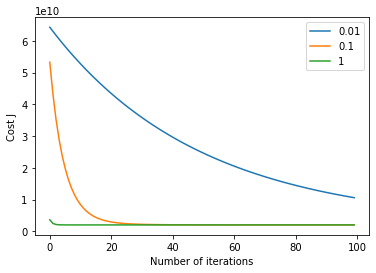

In [48]:
# ================ Multiple alpha =================

alpha_vector = [0.01, 0.1, 1]
num_iters = 100
theta = np.zeros(3)
# plt.plot(X[:,2], y, linestyle='', marker='x', color='r', label='Training data')
# plot the convergence for the three different alpha values in one plot
# ----------------------------------your code -------------------------------------

for i in alpha_vector:
    theta = np.zeros(3)
    theta, j = gradientDescentMulti(X, y, theta, i, num_iters)
    print(f'alpha: {i}-> theta: {theta}, cost: {j[-1]}')
#     plt.plot(X[:, :-2], X.dot(theta), label='Linear Regression')
    plotCostMulti(j, i)

plt.legend(loc='best')
plt.show()

In [50]:
# ================ Normal Equations ================

print ('Solving with normal equations...')

data = np.loadtxt(open("ex1data2.txt", "r"), delimiter=",")
X = data[:, 0:2]
y = data[:, 2]
m = len(y)

# Add intercept term to X
X = np.hstack((np.ones((m, 1)), X))

# Calculate the parameters from the normal equation
theta = normalEqn(X, y)
print('Theta computed from the normal equations: ')
print(theta)

price = np.array([1, 1650, 3]).dot(theta)
print('Predicted price of a 1650 sq-ft, 3 br house (using normal equations):', price)

Solving with normal equations...
Theta computed from the normal equations: 
[89597.90954355   139.21067402 -8738.01911255]
Predicted price of a 1650 sq-ft, 3 br house (using normal equations): 293081.464334972
